In [75]:
# Support vector regression

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy import min, max

In [77]:
# importing dataset

In [78]:
dataset = pd.read_csv('./Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [79]:
# feature scaling

In [80]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
X = sc_X.fit_transform(X)
# reshaping y into a 2D array for transformation
sc_y = StandardScaler() #creating a new scaler object as the mean was already calculated for the object used in scaling X
y = y.reshape(len(y), 1)
y = sc_y.fit_transform(y)

In [81]:
## training the SVR on the whole dataset

In [82]:
from sklearn.svm import SVR

regressor = SVR(kernel='rbf')
regressor.fit(X, y)

C:\Users\nrj66\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [83]:
## predicting a new result

In [84]:
sc_y.inverse_transform(regressor.predict(sc_X.transform([[6.5]])).reshape(-1, 1))

array([[170370.0204065]])

In [85]:
# visualizing the SVR result

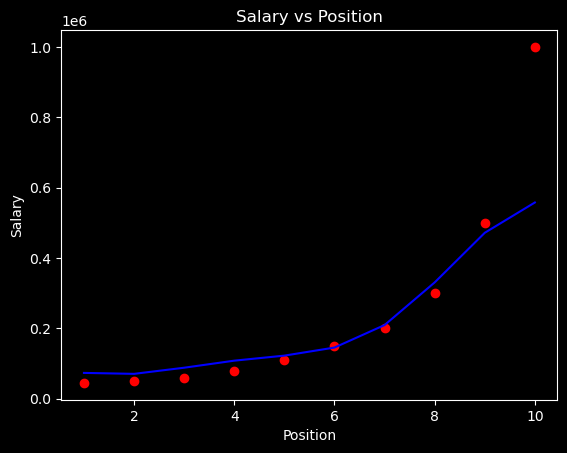

In [86]:
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), c='red')
plt.plot(sc_X.inverse_transform(X), sc_y.inverse_transform(regressor.predict(X).reshape(-1, 1)), c='blue')
plt.title('Salary vs Position')
plt.xlabel('Position')
plt.ylabel('Salary')
plt.show()

In [87]:
## visualizing the SVR result in high resolution

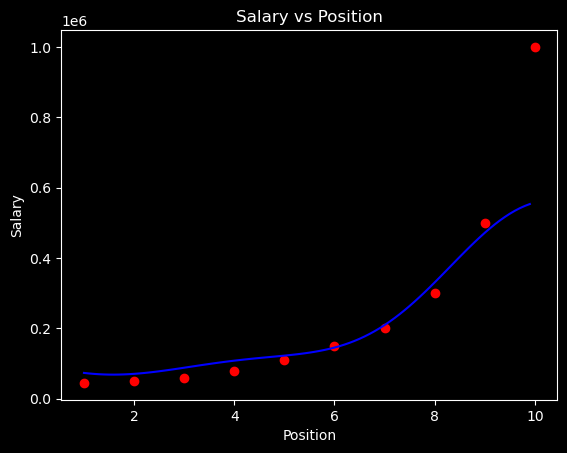

In [88]:
X_grid = np.arange(min(sc_X.inverse_transform(X)), max(sc_X.inverse_transform(X)), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), c='red')
plt.plot(X_grid, sc_y.inverse_transform(regressor.predict(sc_X.transform(X_grid)).reshape(-1, 1)), c='blue')
plt.title('Salary vs Position')
plt.xlabel('Position')
plt.ylabel('Salary')
plt.show()